<img height="100" src="https://i.postimg.cc/gjptBxF4/logo-gas-removebg-preview.png" width="250"/>

Aqui está o Markdown editado. Eu mantive a estrutura original, mas expandi o **Passo 3** e adicionei o **Passo 4** crucial para aplicar a lógica Aditiva que discutimos (trazer o passado para o presente).

Também ajustei o resumo final para focar na entrada do WOFOST.

***

### O Conceito: Encontrar e Normalizar a "Tendência Tecnológica"

O objetivo é separar o efeito do **clima** do efeito da **tecnologia**. Queremos saber quanto a lavoura produziria nos anos passados se tivéssemos usado as máquinas e sementes de hoje (2023).

A fórmula base para a linha de crescimento é:

$Y = \beta_0 + \beta_1 * X$

As variáveis são:
* $Y$ = A produtividade, `yield (kg/ha)`
* $X$ = O ano, `year`
* $\beta_0$ = O **Intercepto** (Base teórica no ano zero).
* $\beta_1$ = A **Inclinação**. Indica quantos kg/ha a produtividade aumenta, *em média*, a cada ano devido à tecnologia.

---

### O Processo de Cálculo (Passo a Passo)

Para preparar os dados para o WOFOST usando o **Método Aditivo**, seguimos estas etapas:

#### Passo 1: Encontrar os Coeficientes ($\beta_0$ e $\beta_1$)

O algoritmo analisou todos os dados de 1984 a 2023 para encontrar a linha reta que melhor se ajusta ao histórico.

Os valores encontrados foram:
* $\beta_0 \text{ (Intercepto)} = \textbf{-255403.414}$
* $\beta_1 \text{ (Inclinação)} = \textbf{128.8316}$

> **Significado:** A tecnologia (sementes, manejo) gera um ganho médio de **128.83 kg/ha por ano**.

#### Passo 2: Calcular a Coluna `yield_trend` (Tendência)

Aplicamos a fórmula para cada ano para descobrir qual seria a produtividade "normal" (sem extremos climáticos) esperada para a tecnologia daquele ano.

Fórmula: `yield_trend` = $-255403.414 + (128.8316 * \text{year})$

* **Para 1984:** `yield_trend` = **3381.332** kg/ha (Tecnologia antiga)
* **Para 2023:** `yield_trend` = **8405.765** kg/ha (Tecnologia atual)

#### Passo 3: Calcular o "Resíduo Climático" (`residuals`)

Aqui calculamos a influência pura do clima. É a diferença entre o que realmente aconteceu e o que a tendência esperava.

Fórmula: `residual` = `yield (Real)` - `yield_trend`

* **Para 1984:** $3140.7 - 3381.333$ = **-240.633**
    * *O clima de 1984 causou um prejuízo de ~240 kg.*
* **Para 2022:** $5070.4 - 8276.934$ = **-3206.534**
    * *O clima de 2022 foi desastroso, tirando ~3.2 toneladas.*

#### Passo 4: Normalização Aditiva (`yield_normalized`)

**Este é o passo final para o WOFOST.**
Trazemos o clima do passado para a tecnologia do presente. Somamos o resíduo de cada ano à tendência do ano mais atual (2023).



Fórmula: `yield_normalized` = `yield_trend (2023)` + `residual (Ano X)`

O valor base da tecnologia de 2023 é **8405.765**.

* **Para o ano 1984 (Normalizado):**
    * Cálculo: $8405.765 + (-240.633)$
    * Resultado: **8165.132 kg/ha**
    * *Interpretação:* Se usássemos a semente de 2023 no clima de 1984, colheríamos 8.1 toneladas.

* **Para o ano 2022 (Normalizado):**
    * Cálculo: $8405.765 + (-3206.534)$
    * Resultado: **5199.231 kg/ha**
    * *Interpretação:* Mesmo com a semente moderna de 2023, o clima ruim de 2022 derrubaria a produção para 5.1 toneladas.

---

### Resumo Final

Para calibrar o modelo, você **não** usará os dados originais brutos. As contas finais foram:

1.  Definimos o patamar tecnológico atual: **~8405 kg/ha**.
2.  Para cada ano histórico, pegamos apenas o "desvio" causado pelo clima (o resíduo).
3.  Aplicamos esse desvio ao patamar atual.

A coluna `yield_normalized` (Passo 4) é a sua variável alvo (`Target`) para a calibração do WOFOST. Ela simula uma série temporal onde a tecnologia é constante (a de 2023) e apenas o clima varia.

# Detrending a single ID for understanding

In [1]:
import os
import pandas as pd
from setuptools.command.rotate import rotate

path = os.path.join(os.getcwd(),'inputs','data','data.feather')
df = pd.read_feather(path)

In [2]:
# --- 1. Preparar Dados para Regressão ---
df1 = df[df['ID'] == '0a50c017'].copy()
df1['date'] = pd.to_datetime(df1['date'], format="%Y-%m-%d")

del df

In [3]:
# Agrupar por ano e ID, calculando a média da produtividade
df1 = df1.groupby([df1['date'].dt.year, 'ID']).agg({
    'country': 'first',
    'state_region': 'first',
    'latitude': 'first',
    'longitude': 'first',
    'yield (kg/ha)': 'mean'
}).reset_index()

# Renomear a coluna 'date' para 'year'
df1.rename(columns={'date': 'year'}, inplace=True)

In [9]:
df1.head(42)

,year,ID,country,state_region,latitude,longitude,yield (kg/ha),yest,residuals,d_yield (kg/ha)
0,1984,0a50c017,United States,Nebraska,41.25,-102.25,7281.0,7172.634146,108.365854,11851.481707
1,1985,0a50c017,United States,Nebraska,41.25,-102.25,8035.0,7289.825985,745.174015,12488.289869
2,1986,0a50c017,United States,Nebraska,41.25,-102.25,8035.0,7407.017824,627.982176,12371.098030
3,1987,0a50c017,United States,Nebraska,41.25,-102.25,8223.0,7524.209662,698.790338,12441.906191
4,1988,0a50c017,United States,Nebraska,41.25,-102.25,7783.0,7641.401501,141.598499,11884.714353
5,1989,0a50c017,United States,Nebraska,41.25,-102.25,7595.0,7758.593340,-163.593340,11579.522514
6,1990,0a50c017,United States,Nebraska,41.25,-102.25,8035.0,7875.785178,159.214822,11902.330675
7,1991,0a50c017,United States,Nebraska,41.25,-102.25,7972.0,7992.977017,-20.977017,11722.138837
8,1992,0a50c017,United States,Nebraska,41.25,-102.25,8474.0,8110.168856,363.831144,12106.946998
9,1993,0a50c017,United States,Nebraska,41.25,-102.25,6528.0,8227.360694,-1699.360694,10043.755159


In [4]:
from sklearn.linear_model import LinearRegression

# X são os Anos. Usamos colchetes duplos [[]] para manter como DataFrame (2D)
X = df1[['year']]

# y é a Produtividade Observada (pode ser 1D)
y = df1['yield (kg/ha)']

# --- 4. Ajustar o Modelo de Regressão Linear ---
modelo_linear = LinearRegression()
modelo_linear.fit(X, y)

# --- 5. Extrair os Coeficientes (β₀ e β₁) ---
# Estes são os coeficientes de tendência para este local específico
beta_0 = modelo_linear.intercept_
beta_1 = modelo_linear.coef_[0]

print(f"--- Coeficientes da Tendência Encontrados (para ID: 17ed5222) ---")
print(f"Beta_0 (Intercepto): {beta_0:.4f}")
print(f"Beta_1 (Inclinação/Ano): {beta_1:.4f} kg/ha por ano")
print(f"Equação da Tendência: Produtividade = {beta_0:.4f} + {beta_1:.4f} * year")
print("\n")

df1['yest'] = modelo_linear.predict(X)
df1['residuals'] = y - df1['yest']
df1['d_yield (kg/ha)'] = df1['residuals'] + (df1['yest'].iloc[-1])

--- Coeficientes da Tendência Encontrados (para ID: 17ed5222) ---
Beta_0 (Intercepto): -225335.9737
Beta_1 (Inclinação/Ano): 117.1918 kg/ha por ano
Equação da Tendência: Produtividade = -225335.9737 + 117.1918 * year




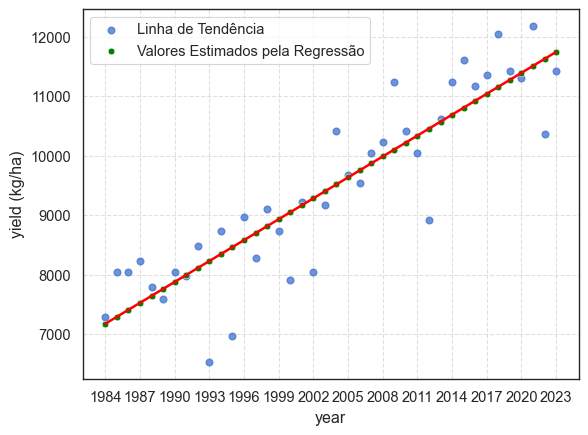

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(context='paper',style="white",palette="muted",font="sans-serif",font_scale=1.2,color_codes=True)
sns.regplot(data=df1, x='year',y='yield (kg/ha)',line_kws=dict(color="red"), ci=None, label='Linha de Tendência')
sns.scatterplot(data=df1, x='year',y='yest',color='green', label='Valores Estimados pela Regressão')

plt.xticks(range(1984,2024,3))

plt.grid(True, linestyle='--', alpha=0.6)

([<matplotlib.axis.XTick at 0x16fa67ebb10>,
 [Text(1984, 0, '1984'),
  Text(1987, 0, '1987'),
  Text(1990, 0, '1990'),
  Text(1993, 0, '1993'),
  Text(1996, 0, '1996'),
  Text(1999, 0, '1999'),
  Text(2002, 0, '2002'),
  Text(2005, 0, '2005'),
  Text(2008, 0, '2008'),
  Text(2011, 0, '2011'),
  Text(2014, 0, '2014'),
  Text(2017, 0, '2017'),
  Text(2020, 0, '2020'),
  Text(2023, 0, '2023')])

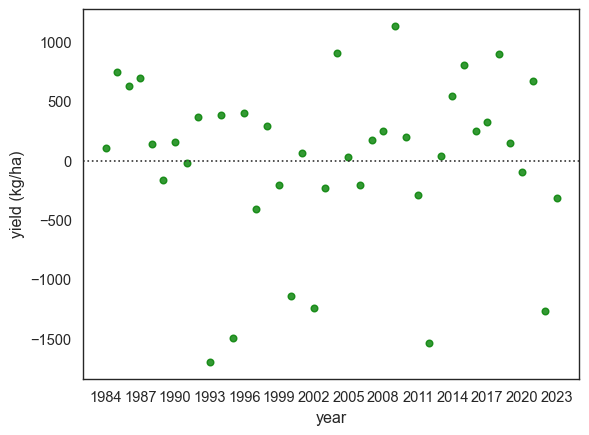

In [17]:
sns.residplot(data=df1, x='year',y='yield (kg/ha)',color='green', label='Valores Estimados pela Regressão')

plt.xticks(range(1984,2024,3))

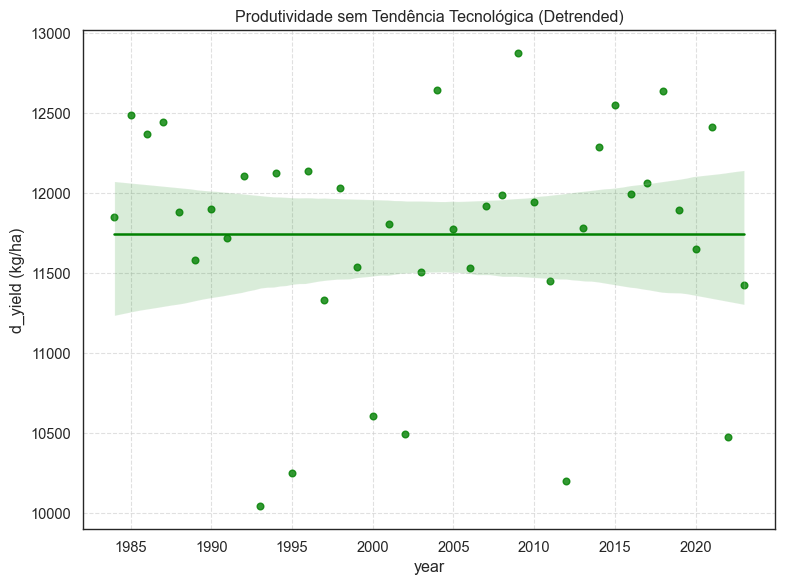

In [28]:
# Subplot com e sem tendência
fig, axs = plt.subplots(1, 1, figsize=(8, 6))
#sns.scatterplot(data=df1, x='year',y='yield (kg/ha)', ax=axs[0], color='blue', label='Produtividade Observada')
#sns.lineplot(data=df1, x='year',y='yest', ax=axs[0], color='red', label='Linha de Tendência')
#axs[0].set_title('Produtividade com Tendência Tecnológica')
#axs[0].grid(True, linestyle='--', alpha=0.6)
sns.regplot(data=df1, x='year',y='d_yield (kg/ha)', color='green', label='Produtividade Detrended')
axs.set_title('Produtividade sem Tendência Tecnológica (Detrended)')
axs.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Detrending the .nc files
~/inputs/data/completo/*.nc

In [3]:
import os
import glob
import numpy as np
import pandas as pd
import xarray as xr
from sklearn.linear_model import LinearRegression
from scipy import stats
from tqdm import tqdm

# Diretório com os arquivos .nc
caminho_arquivos = os.path.join(os.getcwd(),'inputs','data','completo','*.nc')
arquivos_nc = glob.glob(caminho_arquivos)

print("="*80)
print("DETRENDING DE DADOS DE PRODUTIVIDADE")
print("="*80)
print(f"\nEncontrados {len(arquivos_nc)} arquivos .nc para processar...")

erros = []
sucessos = 0

# Processar cada arquivo
for arquivo in tqdm(arquivos_nc, desc="Processando arquivos"):
    try:
        # Abrir dataset e carregar completamente em memória
        with xr.open_dataset(arquivo) as ds:
            ds_loaded = ds.load()  # Carrega tudo em memória

        # Extrair dados de produtividade e tempo
        yield_data = ds_loaded['yield'].values
        time_data = ds_loaded['date'].values

        # Converter tempo para anos
        years = np.array([pd.Timestamp(t).year for t in time_data])

        # Agrupar por ano (média anual)
        df_temp = pd.DataFrame({'year': years, 'yield': yield_data})
        df_anual = df_temp.groupby('year')['yield'].mean().reset_index()

        # Ajustar o Modelo de Regressão Linear
        modelo_linear = LinearRegression()
        X = df_anual[['year']]
        y = df_anual['yield']
        modelo_linear.fit(X, y)

        # Extrair coeficientes
        beta_0 = modelo_linear.intercept_
        beta_1 = modelo_linear.coef_[0]
        r_squared = modelo_linear.score(X, y)

        # Calcular p-valor
        slope, intercept, r_value, p_value, std_err = stats.linregress(df_anual['year'], df_anual['yield'])

        # Calcular tendência para cada ponto temporal
        df_years = pd.DataFrame({'year': years})
        yield_trend = modelo_linear.predict(df_years)

        # Calcular resíduos
        residuals = yield_data - yield_trend

        # Normalização Aditiva
        ultimo_ano = years.max()
        yield_trend_ultimo_ano = beta_0 + (beta_1 * ultimo_ano)
        yield_normalized = yield_trend_ultimo_ano + residuals

        # Adicionar nova variável ao dataset em memória
        ds_loaded['dyield'] = (ds_loaded['yield'].dims, yield_normalized)
        ds_loaded['dyield'].attrs = {
            'long_name': 'Normalized Yield (Detrended)',
            'units': 'kg/ha',
            'description': f'Yield normalized to {ultimo_ano} technology level',
            'reference_year': int(ultimo_ano),
            'beta_0': float(beta_0),
            'beta_1': float(beta_1),
            'p_value': float(p_value),
            'r_squared': float(r_squared)
        }

        # Configurar encoding para compressão
        encoding = {var: {'zlib': True, 'complevel': 5} for var in ds_loaded.data_vars}

        # Salvar em um arquivo temporário e depois substituir o original
        arquivo_temp = arquivo + '.tmp'
        ds_loaded.to_netcdf(arquivo_temp, engine='netcdf4', format='NETCDF4', encoding=encoding, mode='w')

        # Fechar o dataset em memória para liberar recursos
        ds_loaded.close()

        # Substituir o arquivo original pelo temporário
        os.remove(arquivo)
        os.rename(arquivo_temp, arquivo)

        sucessos += 1

    except Exception as e:
        erros.append((os.path.basename(arquivo), str(e)))
        # Se um arquivo temporário foi criado, remove-o em caso de erro
        if 'arquivo_temp' in locals() and os.path.exists(arquivo_temp):
            os.remove(arquivo_temp)


# Relatório final
print("\n" + "="*80)
print("RELATÓRIO FINAL")
print("="*80)
print(f"\nArquivos processados com sucesso: {sucessos}/{len(arquivos_nc)}")
print(f"Erros: {len(erros)}")

if erros:
    print("\n" + "="*80)
    print("Arquivos com erro:")
    for arquivo, erro in erros[:10]:
        print(f"  • {arquivo}: {erro}")

print("\n>>> Detrending concluído! <<<")

DETRENDING DE DADOS DE PRODUTIVIDADE

Encontrados 1506 arquivos .nc para processar...


Processando arquivos: 100%|██████████| 1506/1506 [01:34<00:00, 15.89it/s]


RELATÓRIO FINAL

Arquivos processados com sucesso: 1506/1506
Erros: 0

>>> Detrending concluído! <<<


In [ ]:
ds

In [ ]:
# Considerar